In [ ]:
import numpy as np
import tensorflow as tf
import os
import squidpy as sq
import random

from tifffile import imread
from csbdeep.utils import normalize
from stardist.models import StarDist2D
from shapely.geometry import Polygon
from scipy import sparse
from skimage.filters import threshold_otsu

from typing import Dict
from pathlib import Path
import pickle

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

seed_value = 123

tf.random.set_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)

2026-05-25 15:55:51.507551: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-25 15:55:51.507631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-25 15:55:52.472438: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-25 15:55:53.752986: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/users/PAS2694/aladyevae/.c

In [2]:
def save_stardist_polygons(
    polygons: Dict = None,
    save_dir: str = "./stardist_results"
) -> None:
    """
    Save StarDist polygons to disk as pickle file.
    
    Parameters:
    -----------
    stardist_details : Dict, optional
        Dictionary containing 'coord' from StarDist predictions
    save_path : str
        Path to save the file
    """
    
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    save_path = save_dir / 'nuclei'

    geometries = []
    if 'coord' in polygons:
        # Iterating through each nuclei in the 'polys' DataFrame
        for nuclei in range(len(polygons['coord'])):

            # Extracting coordinates for the current nuclei and converting them to (y, x) format
            coords = [(y, x) for x, y in zip(polygons['coord'][nuclei][0], polygons['coord'][nuclei][1])]

            # Creating a Polygon geometry from the coordinates
            geometries.append(Polygon(coords))
        
    # Save as pickle (preserves exact Python objects)
    data = {
        "polygons": geometries
    }

    with open(save_path.with_suffix('.pkl'), 'wb') as f:
        pickle.dump(data, f)
    
    print(f"Saved {len(geometries)} polygons to {save_path}")

In [ ]:
def predict_and_save_labels(image, save_path, channel = 0, 
                            image_slot = "image",
                            nms_thresh=None, prob_thresh=None,
                            model_name = "2D_paper_dsb2018", 
                            normalize_params = [1,99.8], 
                            threshold = True):

    img_array = image[image_slot]
    img_array = img_array[{"channels": channel}].to_numpy()
    image_threshed = img_array.copy()

    if threshold:
            thresh = threshold_otsu(image_threshed)
            image_threshed[image_threshed < thresh] = 0
    
    image_normalized = normalize(image_threshed, normalize_params[0], normalize_params[1], axis=(0, 1))
    model = StarDist2D.from_pretrained(model_name)

    labels, polys = model.predict_instances_big(image_normalized, prob_thresh=prob_thresh, nms_thresh=nms_thresh,
                                                axes='YXC', block_size=4096, min_overlap=128, context=128, 
                                                normalizer=None, n_tiles=(4,4,1))
    save_stardist_polygons(polys, save_path)
    
    labels_sparse = sparse.csr_matrix(labels)
    save_npz_path = Path(os.path.join(save_path, 'nuclei')).with_suffix('.npz')
    sparse.save_npz(save_npz_path, labels_sparse)

## Original TIF images channels check

In [ ]:
img = imread("/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FFPE_Pilot/Images/IF/ffpeAD2_S3.tif")
img = sq.im.ImageContainer(img, layer="image")

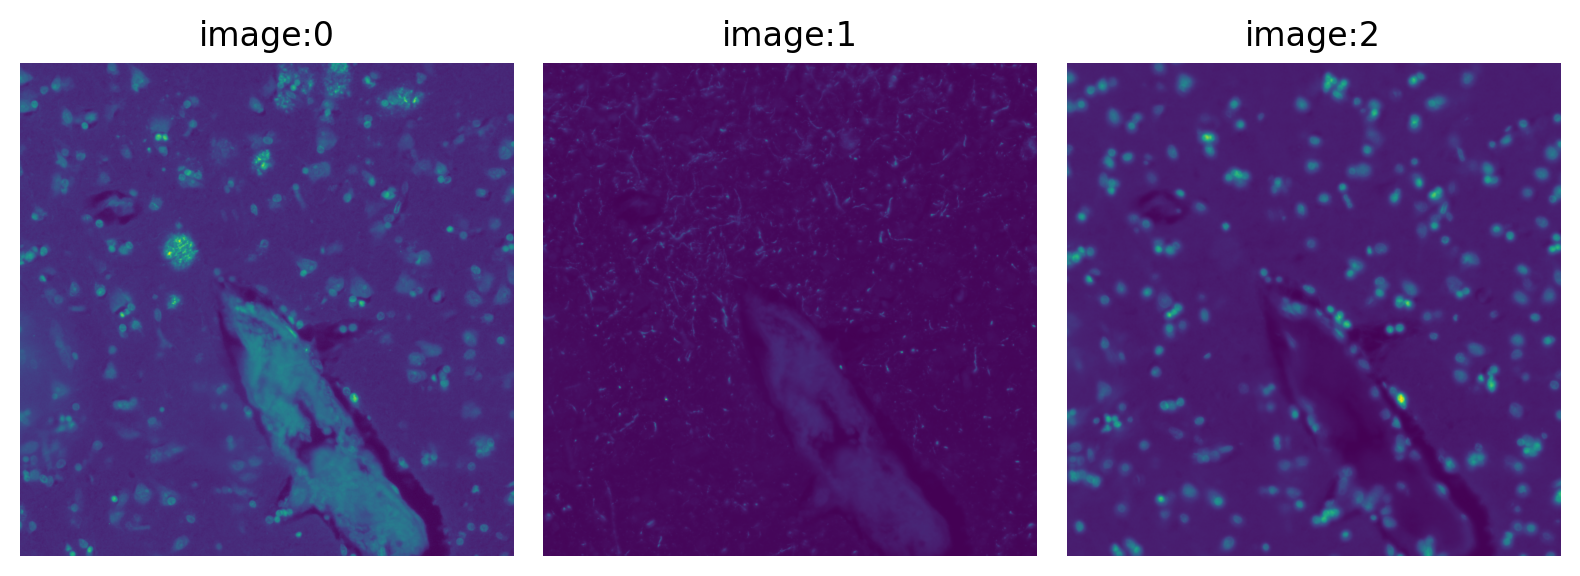

In [5]:
# Load the image and visualize its channels.
crop = img.crop_corner(11300, 3400, size=1000)
crop.show(channelwise=True)

## FFPE Pilot

In [ ]:
images_dict = {
    "ffpeAD2_S3": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Shared/Visium_HD_Pilot/Images/IF/ffpeAD2_S3_intensity.tif",
    "ffpeAD3_S1": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Shared/Visium_HD_Pilot/Images/IF/ffpeAD3_S1_intensity.tif"
}

for sample_id, image_path in images_dict.items():
    channel = 2
    image = imread(image_path)
    image = sq.im.ImageContainer(image, layer="image")
    predict_and_save_labels(image, f"./segmentation/no_threshold_10x/{sample_id}_stardist", 
                            channel = channel, prob_thresh=0.01, nms_thresh=0.001, threshold = False)

## FF Pilot

In [ ]:
images_dict = {
    "AD2_S1": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FF_Pilot/Images/IF/AD2_S1_RGB.tif",
    "AD2_S2": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FF_Pilot/Images/IF/AD2_S2_RGB.tif"
}

for sample_id, image_path in images_dict.items():
    channel = 2
    image = imread(image_path)
    image = sq.im.ImageContainer(image, layer="image")
    predict_and_save_labels(image, f"./segmentation/no_threshold_10x/{sample_id}_stardist", 
                                channel = channel, prob_thresh=0.01, nms_thresh=0.001, threshold = False)

## FF Batch 1

In [ ]:
images_dict = {
    "AD3_S1": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FF_Batch1/Images/IF/AD3_S1_03102026.tiff",
    "AD4_S1": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FF_Batch1/Images/IF/AD4_S1_03102026.tiff",
    "AD5_S1": "/fs/ess/PAS2713/Data/Spatial/VisiumHD/Visium_HD_FF_Batch1/Images/IF/AD5_S1_03102026.tiff"
}

for sample_id, image_path in images_dict.items():
    channel = 2
    image = imread(image_path)
    image = sq.im.ImageContainer(image, layer="image")
    predict_and_save_labels(image, f"./segmentation/no_threshold_10x/{sample_id}_stardist", 
                            channel = channel, prob_thresh=0.01, nms_thresh=0.001, threshold = False)